# EV Battery BMS Microservice: Step 1 & 2 (Damage Simulator Per Charge Cycle)
**Decoupled Architecture: Cloud-Ready Payload Generation**

This notebook trains the physical Battery Management System (BMS) pipeline. 
* **Step 1 (Pre-Flight Check):** Triage based on Time-Zero conditions.
* **Step 2 (Damage Simulator):** Microscopic wear calculation based on session telemetry.
* **Endpoint:** The pipeline terminates by formatting the session data into a JSON API response, ready to be synced to the cloud for the user's mobile app (Step 3).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# ML Imports
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, 
                             mean_absolute_error, r2_score, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay)

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## Step 1: The Pre-Flight Gatekeeper
Trains a Classification model on real-world production telemetry to determine the safest physical charging bound the moment the car plugs in.

Loading Step 1 Production Data...
Step 1 Accuracy: 77.00%

--- Step 1 Advanced Validation Metrics ---
5-Fold CV Mean Accuracy : 78.20%
5-Fold CV Deviation (σ): 3.01%
ROC AUC (OVR, Weighted) : 0.8570
Matthews Corr Coeff     : 0.6506
Cohen’s Kappa           : 0.6487


--- Step 1: Text Feature Importances ---
          Feature  Importance Weight (%)
          SOC (%)                 55.14%
Battery Temp (°C)                 30.78%
      Voltage (V)                  7.11%
Ambient Temp (°C)                  6.97%




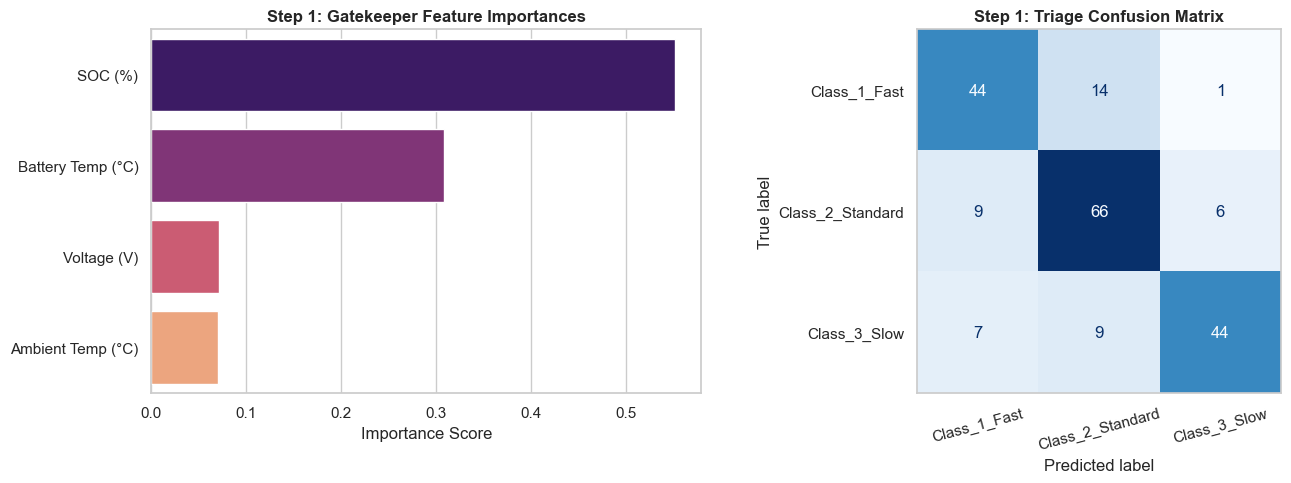

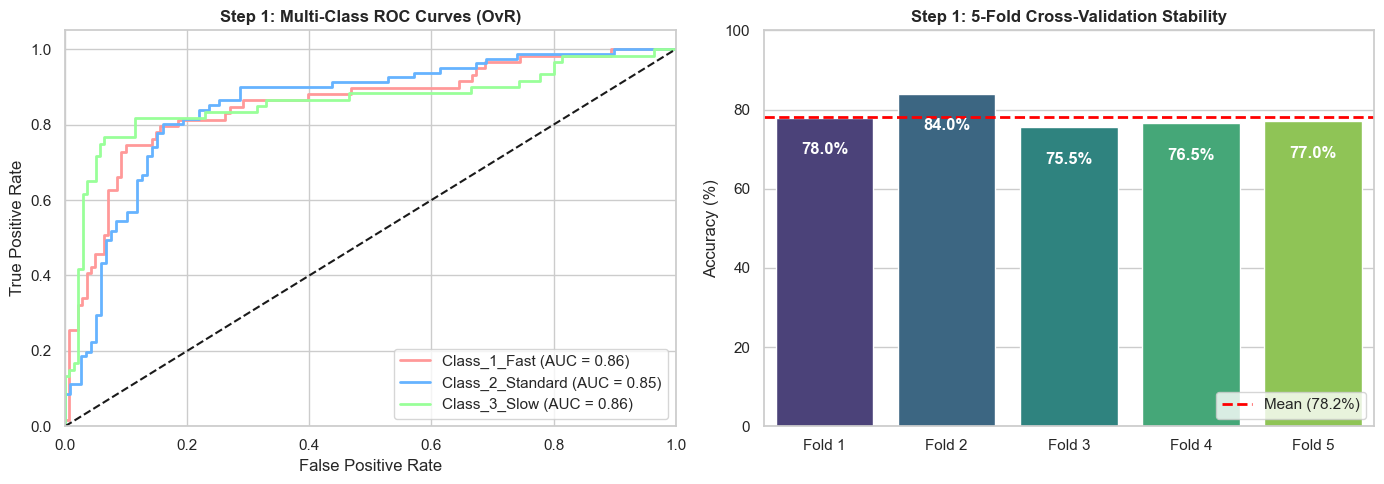


--- Mean Feature Values per Class ---
                  SOC (%)  Voltage (V)  Battery Temp (°C)  Ambient Temp (°C)
Charging Class                                                              
Class_1_Fast        69.99         3.87              32.01              25.01
Class_2_Standard    54.07         3.84              29.98              24.98
Class_3_Slow        35.94         3.85              27.09              24.60




In [2]:
# 1. Import necessary libraries for this section
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import (matthews_corrcoef, cohen_kappa_score, 
                             roc_auc_score, roc_curve, auc)

print("Loading Step 1 Production Data...")
df_step1 = pd.read_csv('production_ev_battery_data.csv')

features_s1 = ['SOC (%)', 'Voltage (V)', 'Battery Temp (°C)', 'Ambient Temp (°C)']
target_s1 = 'Optimal Charging Duration Class'

class_mapping = {0: 'Class_1_Fast', 1: 'Class_2_Standard', 2: 'Class_3_Slow'}
X_s1 = df_step1[features_s1]
y_s1 = df_step1[target_s1].map(class_mapping)

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(X_s1, y_s1, test_size=0.2, random_state=42)

# 2. Train the Model
model_step1 = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
model_step1.fit(X_train_s1, y_train_s1)

# 3. Standard Evaluation
y_pred_s1 = model_step1.predict(X_test_s1)
y_prob_s1 = model_step1.predict_proba(X_test_s1)
print(f"Step 1 Accuracy: {accuracy_score(y_test_s1, y_pred_s1) * 100:.2f}%\n")

# 4. Advanced Reliability & Validation Metrics
print("--- Step 1 Advanced Validation Metrics ---")
cv_scores = cross_val_score(model_step1, X_s1, y_s1, cv=5)
mcc = matthews_corrcoef(y_test_s1, y_pred_s1)
kappa = cohen_kappa_score(y_test_s1, y_pred_s1)

# Binarize labels for multi-class ROC calculations
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_s1)
roc_auc_weighted = roc_auc_score(y_test_bin, y_prob_s1, multi_class='ovr', average='weighted')

print(f"5-Fold CV Mean Accuracy : {cv_scores.mean() * 100:.2f}%")
print(f"5-Fold CV Deviation (σ): {cv_scores.std() * 100:.2f}%")
print(f"ROC AUC (OVR, Weighted) : {roc_auc_weighted:.4f}")
print(f"Matthews Corr Coeff     : {mcc:.4f}")
print(f"Cohen’s Kappa           : {kappa:.4f}\n")

# --- DIAGNOSTIC DASHBOARD 1: FEATURE IMPORTANCE & CONFUSION MATRIX ---
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

importances_s1 = model_step1.feature_importances_
indices_s1 = np.argsort(importances_s1)[::-1]
sorted_features_s1 = [features_s1[i] for i in indices_s1]
# Print Text-Based Feature Importances for Step 1
print("\n--- Step 1: Text Feature Importances ---")
importances_df_s1 = pd.DataFrame({
    'Feature': features_s1,
    'Importance Weight (%)': model_step1.feature_importances_ * 100
}).sort_values(by='Importance Weight (%)', ascending=False)

# to_string() prints a clean text table without the index numbers
print(importances_df_s1.to_string(index=False, float_format="%.2f%%"))
print("\n")
sns.barplot(x=importances_s1[indices_s1], y=sorted_features_s1, palette="magma", ax=axes1[0])
axes1[0].set_title("Step 1: Gatekeeper Feature Importances", fontweight='bold')
axes1[0].set_xlabel("Importance Score")

cm = confusion_matrix(y_test_s1, y_pred_s1, labels=model_step1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_step1.classes_)
disp.plot(ax=axes1[1], cmap="Blues", colorbar=False)
axes1[1].grid(False)
axes1[1].set_title("Step 1: Triage Confusion Matrix", fontweight='bold')
axes1[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# --- DIAGNOSTIC DASHBOARD 2: ROC CURVES & CROSS-VALIDATION STABILITY ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99']

for i, class_label in enumerate(model_step1.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_s1[:, i])
    class_auc = auc(fpr, tpr)
    axes2[0].plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_label} (AUC = {class_auc:.2f})')

axes2[0].plot([0, 1], [0, 1], 'k--', lw=1.5)
axes2[0].set_xlim([0.0, 1.0])
axes2[0].set_ylim([0.0, 1.05])
axes2[0].set_xlabel('False Positive Rate')
axes2[0].set_ylabel('True Positive Rate')
axes2[0].set_title('Step 1: Multi-Class ROC Curves (OvR)', fontweight='bold')
axes2[0].legend(loc="lower right")

fold_labels = [f"Fold {idx+1}" for idx in range(5)]
sns.barplot(x=fold_labels, y=cv_scores * 100, palette="viridis", ax=axes2[1])
axes2[1].axhline(y=cv_scores.mean() * 100, color="red", linestyle="--", lw=2, label=f"Mean ({cv_scores.mean()*100:.1f}%)")
axes2[1].set_ylim([0, 100])
axes2[1].set_ylabel('Accuracy (%)')
axes2[1].set_title('Step 1: 5-Fold Cross-Validation Stability', fontweight='bold')
axes2[1].legend(loc="lower right")

for p in axes2[1].patches:
    axes2[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()
# --- MEAN FEATURE VALUES BY CLASS ---
# 1. Combine features and mapped target into a temporary dataframe
df_analysis = X_s1.copy()
df_analysis['Charging Class'] = y_s1

# 2. Group by the class and calculate the mean for all numerical features
mean_features_by_class = df_analysis.groupby('Charging Class').mean()

# 3. Print the results in a clean text format
print("\n--- Mean Feature Values per Class ---")
print(mean_features_by_class.to_string(float_format="%.2f"))
print("\n")

## Step 2: The Damage Simulator
Trains a Regression model using Arrhenius physics to calculate the exact percentage of microscopic damage incurred during the charging session.

Loading Step 2 Data from 'step2_physics_data.csv' for model training...
Step 2 R-squared (Accuracy): 0.8864


--- Step 2: Text Feature Importances ---
       Physics Stressor  Importance Weight (%)
       Max_Temp_Spike_C                 56.37%
   CV_Charge_Duration_s                 28.61%
High_Voltage_Duration_s                 12.25%
   CC_Charge_Duration_s                  2.77%




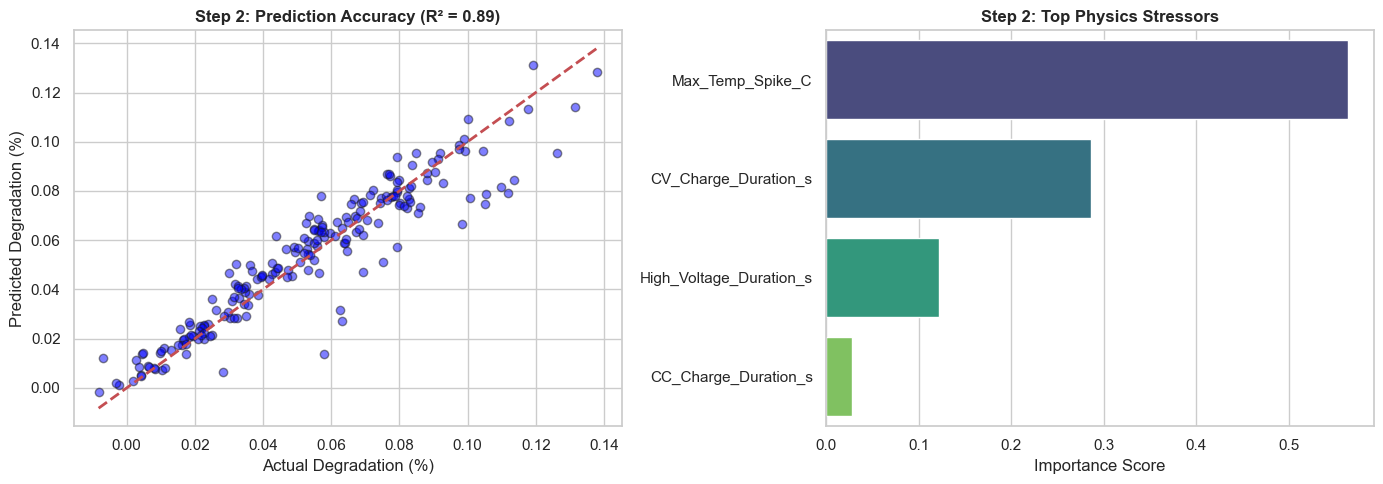

--- Step 2 Advanced Reliability Metrics ---
Mean Absolute Error (MAE)      : 0.00710%
Root Mean Squared Error (RMSE) : 0.01040%
5-Fold CV R² Mean Score        : 0.6073
5-Fold CV R² Deviation (σ)     : 0.0903



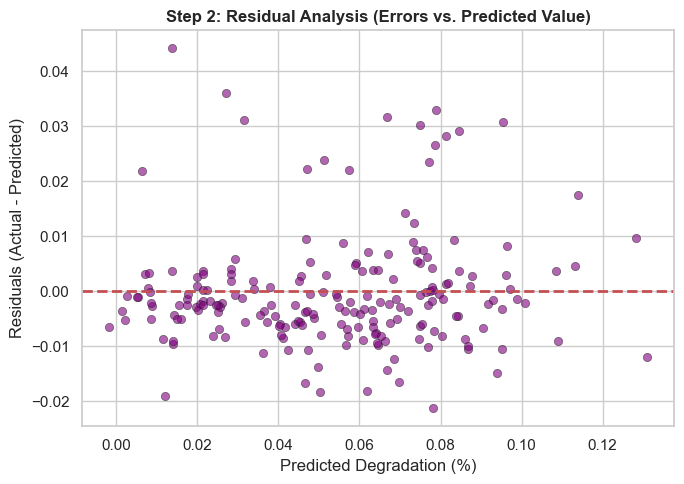

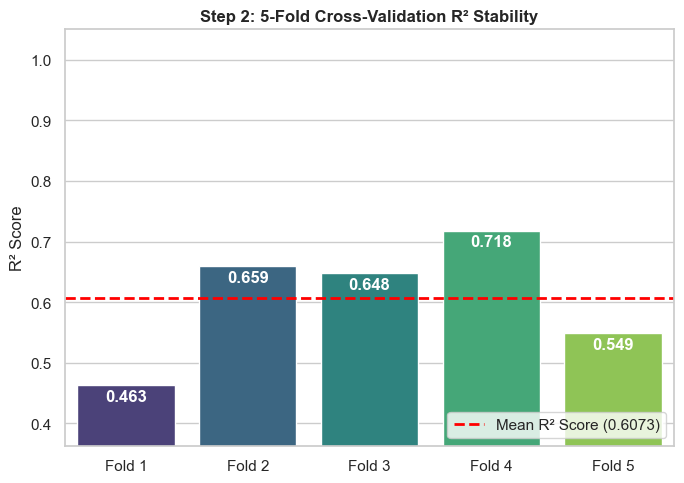

In [3]:
csv_filename = 'step2_physics_data.csv'
print(f"Loading Step 2 Data from '{csv_filename}' for model training...")
df_loaded = pd.read_csv(csv_filename)

features_s2 = ['Max_Temp_Spike_C', 'High_Voltage_Duration_s', 'CC_Charge_Duration_s', 'CV_Charge_Duration_s']
X_s2 = df_loaded[features_s2]
y_s2 = df_loaded['Degradation_Rate_Percent']

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(X_s2, y_s2, test_size=0.2, random_state=42)

# 2. Impute and Train
imputer_s2 = SimpleImputer(strategy='median')
X_train_s2_im = imputer_s2.fit_transform(X_train_s2)
X_test_s2_im = imputer_s2.transform(X_test_s2)

model_step2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_step2.fit(X_train_s2_im, y_train_s2)

y_pred_s2 = model_step2.predict(X_test_s2_im)
r2 = r2_score(y_test_s2, y_pred_s2)
print(f"Step 2 R-squared (Accuracy): {r2:.4f}\n")

# --- VISUALIZATIONS FOR STEP 2 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Actual vs Predicted Wear 
axes[0].scatter(y_test_s2, y_pred_s2, alpha=0.5, color='blue', edgecolor='k')
axes[0].plot([y_test_s2.min(), y_test_s2.max()], [y_test_s2.min(), y_test_s2.max()], 'r--', lw=2)
axes[0].set_title(f"Step 2: Prediction Accuracy (R² = {r2:.2f})", fontweight='bold')
axes[0].set_xlabel('Actual Degradation (%)')
axes[0].set_ylabel('Predicted Degradation (%)')

# Plot B: Physics Drivers
importances_s2 = model_step2.feature_importances_
indices_s2 = np.argsort(importances_s2)[::-1][:8]
sorted_features_s2 = [features_s2[i] for i in indices_s2]

# Print Text-Based Feature Importances for Step 2
print("\n--- Step 2: Text Feature Importances ---")
importances_df_s2 = pd.DataFrame({
    'Physics Stressor': features_s2,
    'Importance Weight (%)': model_step2.feature_importances_ * 100
}).sort_values(by='Importance Weight (%)', ascending=False)

print(importances_df_s2.to_string(index=False, float_format="%.2f%%"))
print("\n")
sns.barplot(x=importances_s2[indices_s2], y=sorted_features_s2, palette="viridis", ax=axes[1])
axes[1].set_title(f"Step 2: Top Physics Stressors", fontweight='bold')
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

# 1. Calculate Absolute and Quadradic Error Bounds
mae_s2 = mean_absolute_error(y_test_s2, y_pred_s2)
rmse_s2 = np.sqrt(mean_squared_error(y_test_s2, y_pred_s2))

print("--- Step 2 Advanced Reliability Metrics ---")
print(f"Mean Absolute Error (MAE)      : {mae_s2:.5f}%")
print(f"Root Mean Squared Error (RMSE) : {rmse_s2:.5f}%")

# 2. 5-Fold Cross-Validation for Regression Stability
# Transform the entire feature set through your imputer to evaluate fairly
X_s2_imputed = imputer_s2.fit_transform(X_s2)
cv_r2_scores = cross_val_score(model_step2, X_s2_imputed, y_s2, cv=5, scoring='r2')

print(f"5-Fold CV R² Mean Score        : {cv_r2_scores.mean():.4f}")
print(f"5-Fold CV R² Deviation (σ)     : {cv_r2_scores.std():.4f}\n")


# 3. Plot Residuals to check for systematic bias
residuals = y_test_s2 - y_pred_s2

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred_s2, y=residuals, alpha=0.6, color='purple', edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Step 2: Residual Analysis (Errors vs. Predicted Value)', fontweight='bold')
plt.xlabel('Predicted Degradation (%)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))
fold_labels = [f"Fold {i+1}" for i in range(5)]

# 1. Plot individual fold R² scores
sns.barplot(x=fold_labels, y=cv_r2_scores, palette="viridis")

# 2. Draw a horizontal reference line for the mean R² score
mean_r2 = cv_r2_scores.mean()
plt.axhline(y=mean_r2, color="red", linestyle="--", lw=2,
            label=f"Mean R² Score ({mean_r2:.4f})")

# 3. Chart Styling & Boundary adjustments
# Dynamically scale the bottom limit if R² drops, otherwise track up to 1.0
ymin = max(0, min(cv_r2_scores) - 0.1) 
plt.ylim([ymin, 1.05])
plt.ylabel('R² Score')
plt.title('Step 2: 5-Fold Cross-Validation R² Stability', fontweight='bold')
plt.legend(loc="lower right")

# 4. Annotate exact metrics inside each bar for presentation scannability
for p in plt.gca().patches:
    # Ensure we only annotate the bar patches, not background elements
    if p.get_height() <= 1.05 and p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.3f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height() - (ymin * 0.05 if ymin > 0 else 0.08)),
                    ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## User I/O: The Damage Simulator
This class wraps Step 1 and Step 2 into a single cohesive unit. When the charging session finishes, it evaluates the total impact.

In [5]:
class EVBatteryMicroservice:
    def __init__(self, s1_model, s2_model, s2_imputer):
        self.step1_model = s1_model
        self.step2_model = s2_model
        self.step2_imputer = s2_imputer

    def process_session(self, t0_data, telemetry_data, vehicle_id="EV-9942"):
        print("="*60)
        print(f"[VEHICLE {vehicle_id}] BMS SMART CHARGE INITIATED")
        print("="*60)
        
        # --- Execute Step 1: Hardware Safety Check ---
        safe_class = self.step1_model.predict(t0_data)[0]
        print(f"Pre-Flight Check: Approved for {safe_class}")
        
        # --- Execute Step 2: Session Wear Calculation ---
        clean_telemetry = self.step2_imputer.transform(telemetry_data)
        damage = self.step2_model.predict(clean_telemetry)[0]
        print(f"Post-Charge Audit: {damage:.5f}% Micro-damage incurred")
        print("="*60)
                
        import datetime
        api_payload = {
            "vehicle_id": vehicle_id,
            "session_status": "COMPLETED",
            "safety_protocol_used": safe_class,
            "degradation_incurred_percent": round(float(damage), 5),
            "timestamp": datetime.datetime.now().isoformat() + "Z"
        }
        
        return json.dumps(api_payload, indent=4)

# Instantiate the refactored microservice
bms_service = EVBatteryMicroservice(model_step1, model_step2, imputer_s2)

# ==========================================
# TEST SCENARIO EXECUTION
# ==========================================

# 1. Car plugs in (Hot & Highly Charged)
incoming_t0 = pd.DataFrame({
    'SOC (%)': [55.0],               
    'Voltage (V)': [8.95],           
    'Battery Temp (°C)': [44.0],     
    'Ambient Temp (°C)': [44.0]      
})

# 2. Charge finishes (Abusive session telemetry)
incoming_telemetry = pd.DataFrame({
    'Max_Temp_Spike_C': [88],
    'High_Voltage_Duration_s': [2100.0],
    'CC_Charge_Duration_s': [2333.0],
    'CV_Charge_Duration_s': [2333.0]
})

# 3. Run the microservice endpoint!
json_response = bms_service.process_session(incoming_t0, incoming_telemetry, vehicle_id="USER-A-TESLA-01")

print(json_response)

[VEHICLE USER-A-TESLA-01] BMS SMART CHARGE INITIATED
Pre-Flight Check: Approved for Class_1_Fast
Post-Charge Audit: 0.12343% Micro-damage incurred
{
    "vehicle_id": "USER-A-TESLA-01",
    "session_status": "COMPLETED",
    "safety_protocol_used": "Class_1_Fast",
    "degradation_incurred_percent": 0.12343,
    "timestamp": "2026-05-30T21:24:13.206946Z"
}
